# The protocol workflow

This tutorial walks through the analyses of the protocol paper (Parkes, Kim et al., *Nature Protocols* 2024) on a
small synthetic connectome: control energy for a transition between two brain states (Procedure 1 and Box 1),
average controllability (Procedure 2), control energy for every pair of states with a pipeline class, and spatial
null networks (Supplementary Information). Variable names follow the paper's printed code, so each step can be
matched to it.

The paper uses a structural connectome from the Philadelphia Neurodevelopmental Cohort. Here everything is
synthetic and seeded, so the page runs anywhere and gives the same numbers every time. The numbers are not the
paper's; the steps are. Running the paper's own code on its data is covered in the protocol paper itself.

Besides nctpy, this page uses matplotlib, seaborn and pandas: `pip install "nctpy[plot]"`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance

from nctpy.energies import get_control_inputs, integrate_u
from nctpy.metrics import ave_control
from nctpy.pipelines import ComputeControlEnergy
from nctpy.plotting import add_module_lines, null_plot, reg_plot, set_plotting_params
from nctpy.utils import convert_states_str2int, get_null_p, matrix_normalization, normalize_state
from null_models.geomsurr import geomsurr

set_plotting_params()

## A synthetic connectome

Real connectomes are spatially embedded: nearby regions are more likely to be connected, and more strongly. The
function below places nodes on a sphere, groups them into seven contiguous systems (named A to G), and connects
pairs with a probability and weight that fall off with distance, a little more likely within a system. It returns
the adjacency matrix, the distance between nodes (used by the null networks later) and each node's system.

In [2]:
def make_connectome(n_nodes=100, n_systems=7, length=0.5, seed=0):
    rng = np.random.default_rng(seed)
    # node coordinates on a unit sphere, ordered by longitude so that systems are contiguous
    xyz = rng.normal(size=(n_nodes, 3))
    xyz /= np.linalg.norm(xyz, axis=1, keepdims=True)
    xyz = xyz[np.argsort(np.arctan2(xyz[:, 1], xyz[:, 0]))]
    names = [chr(ord("A") + i) for i in range(n_systems)]
    labels = [names[i] for i, nodes in enumerate(np.array_split(np.arange(n_nodes), n_systems)) for _ in nodes]
    # connection probability and weight fall off with distance; within-system pairs are twice as likely
    dist = distance.squareform(distance.pdist(xyz, "euclidean"))
    decay = np.exp(-dist / length)
    p = np.where(np.equal.outer(labels, labels), np.minimum(1, 2 * decay), decay)
    edges = np.triu(rng.random((n_nodes, n_nodes)) < p, k=1)
    weights = rng.lognormal(0, 1, size=(n_nodes, n_nodes)) * decay
    A = np.where(edges, weights, 0)
    return A + A.T, dist, labels


adjacency, distance_matrix, system_labels = make_connectome()
n_nodes = adjacency.shape[0]
print(adjacency.shape)
# check for self-connections
print(np.any(np.diag(adjacency) > 0))
# get density
density = np.count_nonzero(np.triu(adjacency, k=1)) / (n_nodes * (n_nodes - 1) / 2)
print(round(density, 3))

(100, 100)
False
0.152


This connectome has no self-connections. The connectome used in the protocol paper does, and nctpy keeps them
as they are: it never zeroes the diagonal unless asked to, with `matrix_normalization(..., zero_diagonal=True)`.

{func}`~nctpy.plotting.add_module_lines` outlines each system on a plot of the matrix:

['A' 'B' 'C' 'D' 'E' 'F' 'G']


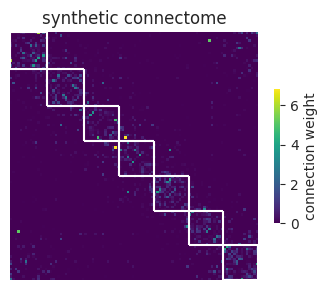

In [3]:
f, ax = plt.subplots(1, 1, figsize=(4, 3.5))
sns.heatmap(adjacency, ax=ax, square=True, cmap="viridis", xticklabels=False, yticklabels=False,
            cbar_kws={"label": "connection weight", "shrink": 0.5})
add_module_lines(pd.Series(system_labels), ax)
ax.set_title("synthetic connectome")
plt.show()

## Procedure 1: control energy for one transition

**Step 1: choose a time system.** Here, continuous time, as in the paper's printed results.

In [4]:
system = "continuous"


**Step 2: normalise the adjacency matrix** so that the system is stable.

In [5]:
adjacency_norm = matrix_normalization(A=adjacency, system=system, c=1)
print(np.max(np.linalg.eigvals(adjacency_norm).real))  # negative: stable

-0.08568399914220204


**Step 3: define the brain states and the control set.** Each system becomes a binary brain state: its nodes are
active and the rest are not. {func}`~nctpy.utils.convert_states_str2int` turns the system labels into integers,
and the initial and target states are picked by name (in the paper, the visual and default mode systems; here,
systems A and D). Each state is normalised to unit magnitude. All nodes are control nodes, with equal weight (a
uniform full control set).

In [6]:
# use list of system names to create states
states, state_labels = convert_states_str2int(system_labels)
print([str(label) for label in state_labels])
print(states)

# extract initial and target states, and normalise their magnitude
initial_state = normalize_state(states == state_labels.index("A"))
target_state = normalize_state(states == state_labels.index("D"))

# specify a uniform full control set
control_set = np.eye(n_nodes)

['A', 'B', 'C', 'D', 'E', 'F', 'G']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6]


**Step 4: compute the control signals and the state trajectory.** `get_control_inputs` returns the state
trajectory, the control signals (both time points × nodes) and two numerical errors.

In [7]:
# set parameters
time_horizon = 1  # time horizon (T)
rho = 1  # mixing parameter for state trajectory constraint
trajectory_constraints = np.eye(n_nodes)  # nodes in state trajectory to be constrained

# get the state trajectory, x(t), and the control signals, u(t)
state_trajectory, control_signals, numerical_error = get_control_inputs(
    A_norm=adjacency_norm,
    T=time_horizon,
    B=control_set,
    x0=initial_state,
    xf=target_state,
    system=system,
    rho=rho,
    S=trajectory_constraints,
)
print(state_trajectory.shape, control_signals.shape)

(1001, 100) (1001, 100)


Then check the errors. The inversion error measures how well conditioned the problem was, and the reconstruction
error how far the trajectory ends from the target state. Both should be below $10^{-8}$; if not, the transition
did not complete, and the paper's Table 1 lists what to try.

In [8]:
thr = 1e-8
print("inversion error = {:.2E} (<{:.2E}={:})".format(numerical_error[0], thr, numerical_error[0] < thr))
print("reconstruction error = {:.2E} (<{:.2E}={:})".format(numerical_error[1], thr, numerical_error[1] < thr))

inversion error = 9.34E-16 (<1.00E-08=True)
reconstruction error = 5.40E-14 (<1.00E-08=True)


**Step 5: visualise the control signals and the neural activity**, before computing energy. As in Box 1 of
the paper, separately for the nodes of the initial state, the nodes of the target state and the bystanders (nodes
in neither).

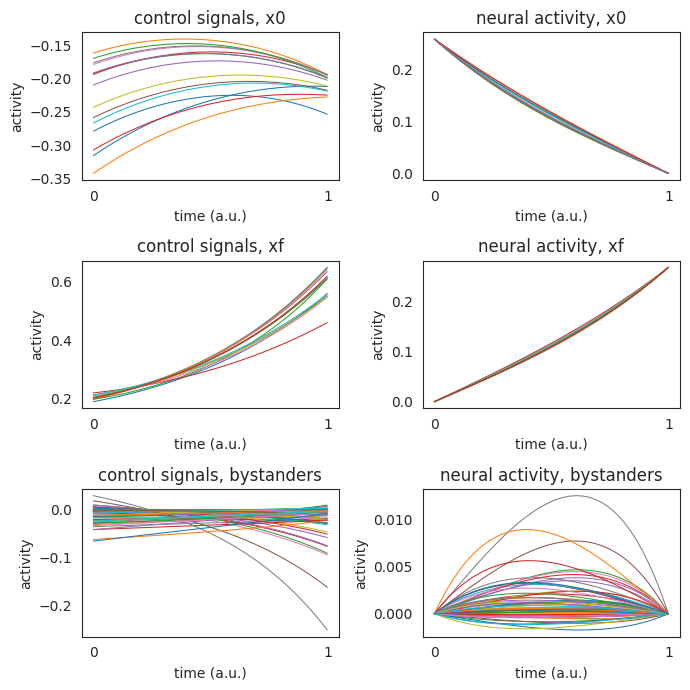

In [9]:
bystanders = np.logical_and(initial_state == 0, target_state == 0)
groups = [("x0", initial_state != 0), ("xf", target_state != 0), ("bystanders", bystanders)]

f, ax = plt.subplots(3, 2, figsize=(7, 7))
for row, (name, nodes) in enumerate(groups):
    ax[row, 0].plot(control_signals[:, nodes], linewidth=0.75)
    ax[row, 0].set_title("control signals, " + name)
    ax[row, 1].plot(state_trajectory[:, nodes], linewidth=0.75)
    ax[row, 1].set_title("neural activity, " + name)
for cax in ax.reshape(-1):
    cax.set_ylabel("activity")
    cax.set_xlabel("time (a.u.)")
    cax.set_xticks([0, state_trajectory.shape[0]])
    cax.set_xticklabels([0, time_horizon])
f.tight_layout()
plt.show()

**Step 6: compute control energy.** Integrating each node's squared control signal over time gives its
energy; their sum is the energy of the transition.

In [10]:
# integrate control signals to get control energy
node_energy = integrate_u(control_signals)
print(node_energy.shape)

# summarize nodal energy
energy = np.sum(node_energy)
print(np.round(energy, 2))

(100,)
2547.17


## Procedure 2: average controllability

Average controllability summarises, for each node, how strongly the system responds to input at that node. In
connectomes it tracks node strength closely, which {func}`~nctpy.plotting.reg_plot` shows:

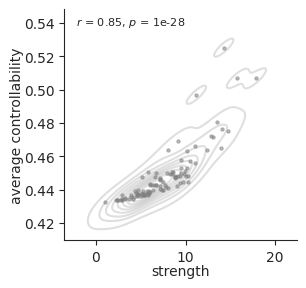

In [11]:
average_controllability = ave_control(A_norm=adjacency_norm, system=system)

f, ax = plt.subplots(1, 1, figsize=(3, 3))
reg_plot(x=np.sum(adjacency, axis=0), y=average_controllability, xlabel="strength",
         ylabel="average controllability", ax=ax, regr_line=False)
plt.show()

## Control energy for every pair of states

{class}`~nctpy.pipelines.ComputeControlEnergy` takes the raw adjacency matrix and a list of control tasks, one dict
per transition, and computes the energy of each. Here, every system to every other system (and to itself):

In [12]:
control_tasks = []
n_states = len(state_labels)
for initial_idx in np.arange(n_states):
    for target_idx in np.arange(n_states):
        control_task = dict()
        control_task["x0"] = normalize_state(states == initial_idx)  # initial state
        control_task["xf"] = normalize_state(states == target_idx)  # target state
        control_task["B"] = control_set  # control set
        control_task["S"] = trajectory_constraints  # state trajectory constraints
        control_task["rho"] = rho  # rho
        control_tasks.append(control_task)

compute_control_energy = ComputeControlEnergy(
    A=adjacency, control_tasks=control_tasks, system=system, c=1, T=time_horizon
)
compute_control_energy.run()

# reshape energy into matrix: rows are initial states, columns target states
energy_matrix = np.reshape(compute_control_energy.E, (n_states, n_states))

The diagonal holds the energy of staying in a state (persistence), which is much lower than that of any
transition, so it is masked to keep the colour scale on the transitions. The asymmetries (right) show which
direction of each transition is cheaper.

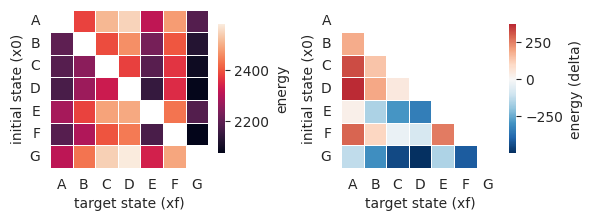

In [13]:
# lower triangle minus upper: energy asymmetries
energy_matrix_delta = energy_matrix.transpose() - energy_matrix

f, ax = plt.subplots(1, 2, figsize=(6, 3))
mask = np.eye(n_states, dtype=bool)  # exclude persistence energy
sns.heatmap(energy_matrix, ax=ax[0], square=True, linewidth=0.5, mask=mask,
            cbar_kws={"label": "energy", "shrink": 0.5})
mask = np.triu(np.ones_like(energy_matrix, dtype=bool))
sns.heatmap(energy_matrix_delta, ax=ax[1], square=True, linewidth=0.5, mask=mask, cmap="RdBu_r", center=0,
            cbar_kws={"label": "energy (delta)", "shrink": 0.5})
for cax in ax:
    cax.set_ylabel("initial state (x0)")
    cax.set_xlabel("target state (xf)")
    cax.set_yticklabels(state_labels, rotation=0)
    cax.set_xticklabels(state_labels, rotation=0)
f.tight_layout()
plt.show()

## Null networks

Is the energy of the A → D transition explained by the connectome's spatial embedding alone? {func}`~null_models.geomsurr.geomsurr`
(Roberts et al., *NeuroImage* 2016) rewires the connectome while preserving the relationship between edge weight
and distance. Its two surrogates used here also preserve the distribution of node strengths (`Wsp`) or each node's
strength (`Wssp`). Each surrogate is normalised and the energy recomputed. The paper uses 5000 permutations; here
200 keep the page quick.

In [14]:
n_perms = 200
energy_null_sp = np.zeros(n_perms)
energy_null_ssp = np.zeros(n_perms)

for perm in np.arange(n_perms):
    _, Wsp, Wssp = geomsurr(W=adjacency, D=distance_matrix, seed=perm)
    for W, energy_null in ((Wsp, energy_null_sp), (Wssp, energy_null_ssp)):
        _, control_signals, _ = get_control_inputs(
            A_norm=matrix_normalization(A=W, system=system),
            T=time_horizon,
            B=control_set,
            x0=initial_state,
            xf=target_state,
            system=system,
            rho=rho,
            S=trajectory_constraints,
        )
        energy_null[perm] = np.sum(integrate_u(control_signals))

{func}`~nctpy.utils.get_null_p` gives the proportion of the null at least as large as the observed energy, and
{func}`~nctpy.plotting.null_plot` draws the null distribution with the observed value. A small p-value would mean
that the transition costs more in the connectome than its spatial embedding and strengths alone would predict.

Wsp: p = 0.060
Wssp: p = 0.410


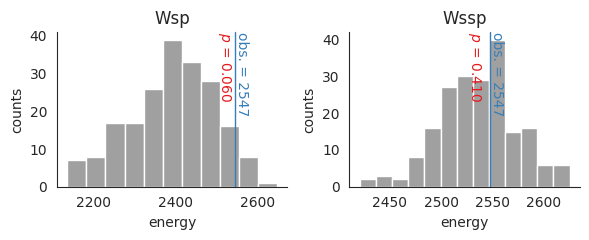

In [15]:
f, ax = plt.subplots(1, 2, figsize=(6, 2.5))
for cax, energy_null, title in ((ax[0], energy_null_sp, "Wsp"), (ax[1], energy_null_ssp, "Wssp")):
    p_val = get_null_p(energy, energy_null)
    null_plot(observed=energy, null=energy_null, xlabel="energy", ax=cax, p_val=p_val)
    cax.set_title(title)
    print("{}: p = {:.3f}".format(title, p_val))
f.tight_layout()
plt.show()

`geomsurr`'s surrogates have no self-connections. For a connectome that has them, compute the observed energy
on its zero-diagonal version, so that observed and surrogate differ only in the rewiring.

## Next steps

- The {doc}`/api/index` documents every function used here, including the options not covered: discrete time,
  reference states (`xr`), partial or weighted control sets, and
  {class}`~nctpy.pipelines.ComputeOptimizedControlEnergy`.
- The protocol paper's Supplementary Information covers variations on these steps: brain states from resting-state
  clusters, control sets weighted by brain maps, and optimised control weights.